# <font color='CB6D51'>Sequence Helper Tutorial</font>
This notebook is a tutorial on using the Sequencer Helper library to make sequencing and connecting to inputs/outputs on the Qblox Cluster faster and more user-friendly.\
This tutorial will go over the library, how to access its functions, how to use each function and describe its limitations. Not every situation will be compatible with this library, but a lot of the basic functionalities of the Qblox Cluster can be achieved faster and easier using these functions.

Author: Kyle MacRobbie

---
## Setup

This is extra code that needs to be ran before starting the tutorial in order to import all the necessary packages and make a connection to the cluster and its modules.

Ensure that the cluster and oscilloscope are turned on before beginning this tutorial.

In [7]:
import pyvisa
from typing import TYPE_CHECKING, Callable
from qcodes.instrument import find_or_create_instrument
from qblox_instruments import Cluster, ClusterType
from qblox_instruments.qcodes_drivers.module import Module

In [8]:
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"
cluster = find_or_create_instrument(
    Cluster,
    recreate=True,
    name=cluster_name,
    identifier=cluster_ip,
    dummy_cfg=(
        {
            2: ClusterType.CLUSTER_QCM,
            4: ClusterType.CLUSTER_QRM,
            6: ClusterType.CLUSTER_QCM_RF,
        }
        if cluster_ip is None
        else None
    ),
)
cluster.led_brightness('medium') # Sets LED brightness on the modules. Options are 'low', 'medium' and 'high'
def get_connected_modules(cluster: Cluster, filter_fn: Callable | None = None) -> dict[int, Module]:
    def checked_filter_fn(mod: ClusterType) -> bool:
        if filter_fn is not None:
            return filter_fn(mod)
        return True
    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }
modules = get_connected_modules(cluster)
module = list(modules.values())[0]
cluster.reset()
print(cluster.get_system_status())
# Assigning modules
qrm_module = modules[4]
qcm_module = modules[2]
rf_module = modules[6]
# Connecting to the osciloscope
rm = pyvisa.ResourceManager()
scope = rm.open_resource('GPIB0::8::INSTR')

Status: OKAY, Flags: NONE, Slot flags: NONE


---
## <font color='#7FFFD4'>Accessing the library</font>
In order to use the functions in the Sequence Helper library, use the following code.

In [9]:
import sys
sys.path.append(r"C:\\Users\\BaughLaflamme\\Desktop\\Qblox Master Folder\\Cluster\\Libraries\\Qblox Sequence Helper")
import sequence_helper as sh

sys.path.append() gives the current notebook access to the folder that the sequence_helper.py file is in.

Now, all Sequence Helper functions can be called by using the library name name 'sh'.

---

## <font color='#7FFFD4'>Module naming convention</font>

In certain functions, the type of module being used will be verified using the variable name you have given your module in Pyhton. For this reason the following naming convention needs to be followed:
- The variable name for the QRM needs to start with 'qrm'
- The variable name for the QCM needs to start with 'qcm'
- The variable name for the QCM-RF cannot start with 'qcm' or 'qrm'

I would suggest using the following:
- qrm_module for the QRM
- qcm_module for the QCM
- rf_module for the QCM-RF

---

## <font color='#7FFFD4'>make_waveforms()</font>


make_waveforms will make a dictionary of waveforms in the Q1ASM format based on a dictionary that you give it with the specified parameters.

The dictionary you give it will have the form:\
{\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;'name' : [type, length, magnitude, index]\
}\
or for ramp steps, a different format is followed:\
{\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;'name': [type, length, initial voltage, final voltage, index]\
}

Supported waveform types for make_waveforms() are:
- 'block'
- 'gaussian'
- 'sine'
- 'cosine'
- 'ramp'

See the following example.

In [5]:
# Define the specs for our waveforms
waveform_specs = {
	'sine wave': ['sine', 1000, 1, 0],
	'cosine wave': ['cosine', 800, 0.8, 1],
	'gaussian pulse': ['gaussian', 1000, 1, 2],
	'block pulse': ['block', 500, 1, 3],
	'ramp pulse': ['ramp', 1000, -0.5, 0.5, 4]
}

# Now send our specs into make_waveforms(), and get the waveform dictionary in the Q1ASM format
waveforms = sh.make_waveforms(waveform_specs)

# Now we can see our Q1ASM formatted dictionary
waveforms

{'sine wave': {'data': [0.0,
   0.006283143965558951,
   0.012566039883352607,
   0.018848439715408175,
   0.02513009544333748,
   0.03141075907812829,
   0.03769018266993454,
   0.04396811831786491,
   0.050244318179769556,
   0.05651853448202453,
   0.06279051952931337,
   0.0690600257144058,
   0.07532680552793272,
   0.08159061156815754,
   0.08785119655074318,
   0.09410831331851433,
   0.1003617148512149,
   0.10661115427525991,
   0.11285638487348168,
   0.11909716009486974,
   0.12533323356430426,
   0.1315643590922825,
   0.13779029068463808,
   0.14401078255225216,
   0.15022558912075706,
   0.15643446504023087,
   0.16263716519488358,
   0.1688334447127339,
   0.17502305897527606,
   0.18120576362713736,
   0.18738131458572463,
   0.19354946805086026,
   0.19970998051440703,
   0.20586260876988133,
   0.21200710992205463,
   0.21814324139654254,
   0.22427076094938117,
   0.23038942667659057,
   0.2364989970237247,
   0.24259923079540743,
   0.2486898871648548,
   0.25477072

## Troubleshooting make_waveforms()

If you put in an incorrect waveform type, you will receive an error message.

In [ ]:
waveform_specs2 = {
	'pulse': ['abcd', 1000, 1, 0]
}

waveforms2 = sh.make_waveforms(waveform_specs2)

---
## <font color='#7FFFD4'>plot_waveforms()</font>

plot_waveforms() will take a dicitonary of Q1ASM formatted waveforms, like the output of make_waveforms(), and plots them.

Let's plot the waveforms we just made:

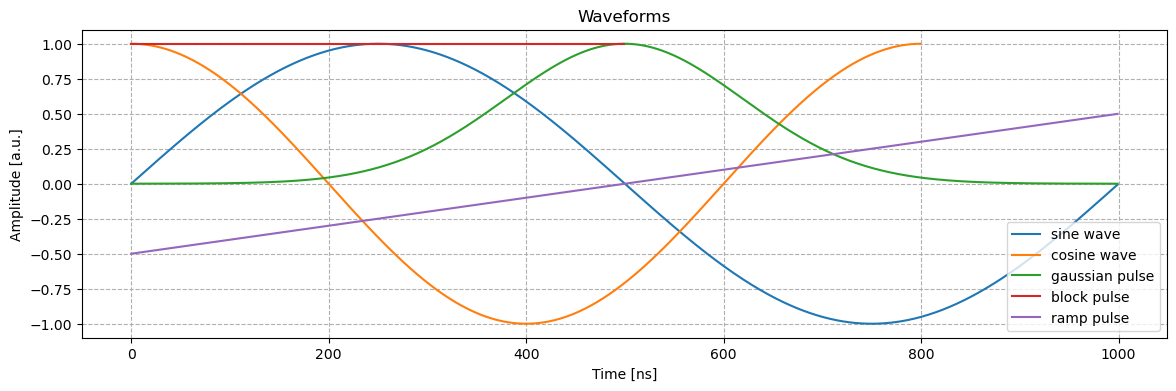

In [11]:
sh.plot_waveforms(waveforms)

---
## <font color='#7FFFD4'>marker_only_sequence()</font>

marker_only_sequence() returns a sequence for the QCM-RF module that simply turns marker 1 on and off again after 500 ns. This is done since the marker is hooked up to the QCM-RF, and sometimes you need to use the marker without using the QCM-RF outputs.

## <font color='#7FFFD4'>connect_marker_only()</font>

connect_marker_only() take a module and sequencer index and sets up the output for the marker, by simply enabling the sync between the given sequencer and the rest of the sequencers.

## <font color='#7FFFD4'>disconnect_io()</font>

disconnect_io() takes a module and will disconnect the outputs, as well as inputs if its a QRM, to make room for the connections you are about to make to those ports.

See the following example, with the oscilloscope set to display the marker output, and trigger off of the marker channel.

In [ ]:
# Setting the oscilloscope ranges
scope.write(f'TIME_DIV {500e-9} S')		# Set the time scale on all oscilloscope channels
scope.write(f'C4:VOLT_DIV {2} V')	# Set the voltage scale on channel 1
scope.write(f'TRIG_DELAY {0}')		# Set the time scale left/right on the display
scope.write(f'TRIG_MODE SINGLE')		# Set the trigger mode to "single" in order to take one acquisition

In [8]:
# Disconnect any inputs or outputs
sh.disconnect_io(rf_module)

# Upload the sequence to the sequencer
rf_module.sequencer0.sequence(sh.marker_only_sequence())

# Connecting the output
sh.connect_marker_only(module = rf_module, sequencer = 0)

# Arming the sequencer
rf_module.arm_sequencer(0)

# Playing the sequence
cluster.start_sequencer()

In [ ]:
# Stopping and resetting
cluster.stop_sequencer()
print("RF sequencer 0:  " + str(rf_module.get_sequencer_status(0)))
cluster.reset()
print(cluster.get_system_status())

## Troubleshooting marker_only_sequence()

If the oscilloscope will not trigger, ensure that:
- You are consistent with your sequencer index in your code
- The marker is connected to the oscilloscope
- The oscilloscope is set to trigger on the channel that the marker is being played in to, at a reasonable volage level (marker outputs 3.3 V)

---
## <font color='#7FFFD4'>make_output_sequence()</font>

make_output_sequence() generates an output sequence for a baseband module based on the input list given to the function. It also takes the name of the module, being either 'qcm' or 'qrm'.\
It also takes an optional variable named 'iterations', if you are playing the same sequence multiple times and averaging, set this number to the number of loops you would like to do. If you wish to only play the sequence once, you do not need to write anything and 'iterations' will default to 1.\
There is also an option to pass 'plot = True' into the function. If this is chosen, a plot of the waveforms used to make the output is printed. If you do not wish to get this plot, you don't need to write anything.

The list given to the function contains the information about each step, with each step itself being another list.
Each step can either be a square pulse or a ramp. The format for a square pulse is:\
[\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[type, length, magnitude]\
]\
And for a ramp:\
[\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[type, length, start value, end value]\
]

The supported step types for make_output_sequence() are:
- square
- ramp

The steps will play in the order in which they are placed in the list.

If you are using make_output_sequence(), you will not need to generate the waveforms yourself using make_waveforms().

If the total length of all ramp steps is less than 16384 ns, then waveforms can be used to perform the ramping, as opposed to manually setting the AWG offset for each step in the ramp. If this condition is met, the ramps will be performed with a resolution of 1 ns.\
However, if there is more than 16384 ns worth of ramping, then there will be too much ramping to be stored in waveforms, and a series of set_awg_offs commands will be played to step through the voltages in the ramp. Since there is a limit to the number of commands that can be loaded into the Q1ASM sequence (12288), and it takes multiple commands to set an offset, there is limit of 6094 voltage steps for the entire sequence. This means the resolution of your output sequence will be:\
resolution = ceil(duration / 6094 ns)\
So if you are making an acquistion that is 1 ms long:\
resolution = ceil(1 ms / 6094 ms) = 165 ns\
Note that there is a minimum resolution of 8 ns for this method, as that is the smallest time that can be used in the upd_param command.

## <font color='#7FFFD4'>connect_output()</font>

connect_output() takes a module, sequencer index, output index and path index, and sets up the connection between a sequencer and an output.

See the following examples, playing from the first QRM output to the oscilloscope channel 1, set to trigger on the marker from the QCM-RF module. We will do one with less than 16384 ns of ramping, and one with more than 16384 of ramping.

In [4]:
# Setting the oscilloscope ranges
scope.write(f'TIME_DIV {1000e-9} S')	# Set the time scale on all oscilloscope channels
scope.write(f'C1:VOLT_DIV {0.15} V')	# Set the voltage scale on channel 1
scope.write(f'TRIG_DELAY {0}')			# Set the time scale left/right on the display
scope.write(f'TRIG_MODE NORMAL')		# Set the trigger mode to "single" in order to take one acquisition

18

In [10]:
# Creating our output step
output_sequence = [
	['square', 1000, 0.4],
	['ramp', 1000, 0.4, -0.2],
	['ramp', 1000, -0.2, 0]
]

# Disconnecting any input and outputs
sh.disconnect_io(qrm_module)
sh.disconnect_io(rf_module)

# Uploading sequences to their respective sequencer
# Note that sequencer 0 for one module is separate from sequencer 0 for any other module, so you can use sequencer 0 for multiple
# modules at the same time.
qrm_module.sequencer0.sequence(sh.make_output_sequence(output_sequence, module = "qrm"))
rf_module.sequencer0.sequence(sh.marker_only_sequence())

# Connect inputs and outputs
sh.connect_output(module = qrm_module, sequencer = 0, output_index = 0, path = 0)
sh.connect_marker_only(module = rf_module, sequencer = 0)

# Arm sequencers
qrm_module.arm_sequencer(0)
rf_module.arm_sequencer(0)

# Start sequencers
cluster.start_sequencer()

In [6]:
# Stopping and resetting
cluster.stop_sequencer()
print("QRM sequencer 0:  " + str(qrm_module.get_sequencer_status(0)))
cluster.reset()
print(cluster.get_system_status())

QRM sequencer 0:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE


Now for a longer sequence

In [7]:
# Setting the oscilloscope ranges
scope.write(f'TIME_DIV {5000e-9} S')		# Set the time scale on all oscilloscope channels
scope.write(f'C1:VOLT_DIV {0.1} V')	# Set the voltage scale on channel 1
scope.write(f'TRIG_DELAY {-20e-6}')		# Set the time scale left/right on the display
scope.write(f'TRIG_MODE NORMAL')		# Set the trigger mode to "single" in order to take one acquisition

18

In [8]:
# Specifying our output steps
output_sequence = [
	['ramp', 10000, 0, 0.3],
	['square', 5000, 0.3],
	['ramp', 10000, 0.3, -0.2],
	['square', 3000, -0.2],
	['ramp', 10000, -0.2, 0.0]
]

# Disconnecting inputs and outputs
sh.disconnect_io(qrm_module)
sh.disconnect_io(rf_module)

# Uploading the sequences to their respective sequencers
qrm_module.sequencer0.sequence(sh.make_output_sequence(output_sequence, module = "qrm"))
rf_module.sequencer0.sequence(sh.marker_only_sequence())

# Connecting the inputs and outputs
sh.connect_output(module = qrm_module, sequencer = 0, output_index = 0, path = 0)
sh.connect_marker_only(module = rf_module, sequencer = 0)

# Arming sequencers
qrm_module.arm_sequencer(0)
rf_module.arm_sequencer(0)

# Starting the sequence
cluster.start_sequencer()

resolution for qrm output: 8


In [9]:
# Stopping and resetting
cluster.stop_sequencer()
print("QRM sequencer 0:  " + str(qrm_module.get_sequencer_status(0)))
cluster.reset()
print(cluster.get_system_status())

QRM sequencer 0:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE


---
## <font color='#7FFFD4'>make_input_sequence()</font>

make_input_sequence() takes a list containing the information about an acquisition and returns a sequence in Q1ASM format to execute the specified acquisition.

It also takes an optional variable named 'iterations', if you are playing the same sequence multiple times and averaging, set this number to the number of loops you would like to do. If you wish to only play the sequence once, you do not need to write anything and 'iterations' will default to 1.

The input list takes the following form:\
[\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[name, delay, duration]\
]

If an acquisition of 16384 ns or less is given, then the input data is taken with a resolution of 1ns.\
If the acquisition is longer than 16384 ns, there is an option to enter a resolution to the function. This is not necessary, and if no value is given, it defaults to 300 ns. See the section on plot_input() for more details on resolution.

## <font color='#7FFFD4'>connect_input()</font>

connect_input() takes a module, sequencer index, input index, and path index and sets up the connection between a sequencer and an input.\
There is also an option of specifying a resolution for inputs greater than 16384 ns. See the section on plot_input() for more details on resolution.

## <font color='#7FFFD4'>plot_input()</font>

plot_input() will take a module, sequencer index and acquisition name, and print a plot of the acquisition stored in the specified sequencer, provided there is an acquisition stored there.
You can also pass optional variables 'path' and 'range'. If you wish to only plot one path, you can set 'path' to 0 or 1, if you wish to plot both, write nothing and it will default to both. If you wish to only plot a certain part of the input, you can pass a list into 'range' formatted as:\
[start, end]\
If you do not wish to control the range, write nothing and it will default to the full range

plot_input() can accept acquisitions that are either within the single acquisition limit of 16384 ns, or greater.

If the acquisition is 16384 ns or less, the entire acquisition can be stored in the scope data of one acquisition, with 1 ns resolution.

However, if the acquisition is greater than 16384 ns, the data is assumed to be stored in the bins, with a default resolution of 300 ns per bin. This is accomplished by having a new acquisition every 300 ns, and integrating the data into a bin, and diving that result by 300 such that the bin value is now the average input value of its respective 300 ns of acquisition time.\
300 ns is chosen since it is almost the smallest resolution you can have using this binning method without getting an error upon trying to make the acquisition, since the integrating and binning can only keep up with the sequence looping to an extent, and enough time is needed between consecutive acquisitions to ensure that they do not fall behind and crash the sequence.

A maximum of 131072 bins can be used in an acquisition, and with a resolution of 300 ns per bin, the maximum acquistion time in this configuration is \
131072 bins $\times$ 300 ns/bin $\approx$ 39 ms 

The absolute maximum acquisition time would be acheived if the resolution is set to the maximum acquisition time, being 16384 ns, giving\
131072 bins $\times$ 16384 ns/bin $\approx$ 2 s

If you need an acquisition greater than 39 ms, this can be accomplished by changing the resolution in the arguements of the make_input_sequence() and connect_input() functions. Again, if a resolution is not specified, 300 ns is used as default.

In the following example, we will take two inputs, one greater than 16384 ns and one less than 16384 ns, and plot them both.

See the following example:

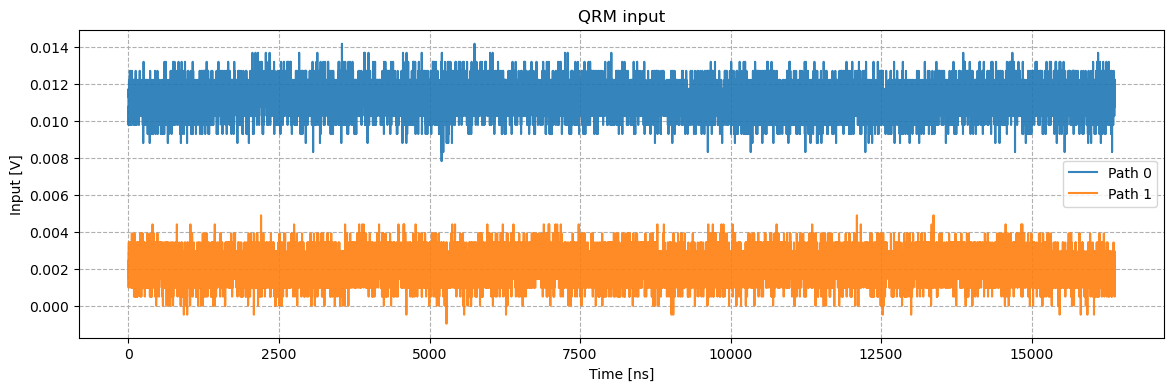

In [10]:
# Disconnect inputs and outputs
sh.disconnect_io(qrm_module)

# Upload the sequence to its sequnecer
qrm_module.sequencer0.sequence(sh.make_input_sequence(['acq', 0, 1000]))

# Connect the input
sh.connect_input(module = qrm_module, sequencer = 0, input_index = 0, path = 0)

# Arm the sequecer
qrm_module.arm_sequencer(0)

# Start the sequence
cluster.start_sequencer()

# Plot the acquisition
sh.plot_input(module = qrm_module, sequencer = 0, acquisition_name = 'acq')

In [11]:
# Stopping and resetting
cluster.stop_sequencer()
print("QRM sequencer 0:  " + str(qrm_module.get_sequencer_status(0)))
cluster.reset()
print(cluster.get_system_status())

QRM sequencer 0:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, ACQ_SCOPE_DONE_PATH_0, ACQ_SCOPE_DONE_PATH_1, ACQ_BINNING_DONE, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE


Now for a longer acquisition:

resolution in plot_input: 500


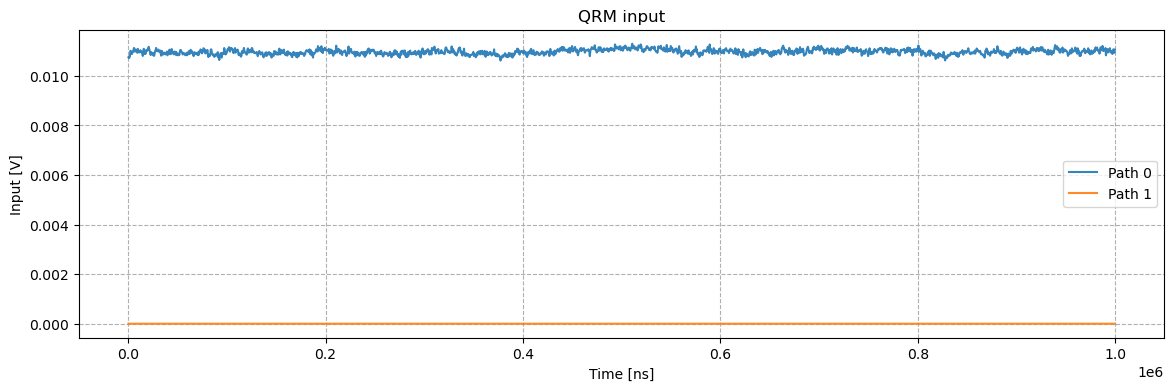

In [12]:
# Disconnect inputs and outputs
sh.disconnect_io(qrm_module)

# Upload the sequence to its sequnecer
qrm_module.sequencer0.sequence(sh.make_input_sequence(['acq', 0, 1e6], resolution = 500)) # 1 millisecond

# Connect the input
sh.connect_input(module = qrm_module, sequencer = 0, input_index = 0, path = 0, resolution = 500)

# Arm the sequecer
qrm_module.arm_sequencer(0)

# Start the sequence
cluster.start_sequencer()

# Plot the acquisition
sh.plot_input(module = qrm_module, sequencer = 0, acquisition_name = 'acq')

In [13]:
# Stopping and resetting
cluster.stop_sequencer()
print("QRM sequencer 0:  " + str(qrm_module.get_sequencer_status(0)))
cluster.reset()
print(cluster.get_system_status())

QRM sequencer 0:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, ACQ_SCOPE_DONE_PATH_0, ACQ_SCOPE_DONE_PATH_1, ACQ_BINNING_DONE, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE


## Troubleshooting inputs

If you get an error message while plotting saying that the acquisition name is not recognized, ensure that you are plotting before running any cluster.reset(), as this will erase the acquistion.

If you get an error named ACQ_BINNING_FIFO_ERROR, this may mean that the resolution is too low and you need to change it to a larger number.

---
## <font color='#7FFFD4'>make_rf_sequence()</font>

make_rf_sequence() will generate a Q1ASM sequence to play RF pulses, as well as wait times. It takes a list of steps, with each step itself being a list. It also takes a value to indicate whether or not to use the marker.

It also takes an optional variable named 'iterations', if you are playing the same sequence multiple times and averaging, set this number to the number of loops you would like to do. If you wish to only play the sequence once, you do not need to write anything and 'iterations' will default to 1.

The input list will take the following form for wait commands:\
[\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[type, length]\
]\
And for modulated square pulses:\
[\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[type, length, magnitude]\
]\
With the magnitude being in volts.

The supported step types for make_rf_sequence() are:
- wait
- square

These steps can be as long as you want them, and are not limited by the 16384 ns limit.

The marker can either be set to 0, 1 or 'both'. Note that because of the design of the QCM-RF, to turn on an output, you need to turn on the marker for that output. This means setting marker = 0 will enable the first marker and the first output. Setting marker = 1 will enable the second marker and second output. <font color='#BC504B'>**In order to use an output on the QCM-RF, its marker must be enabled.**</font>

Note also that in make_rf_sequence() the marker will only come on once a play command is met. This means if you have a wait command at the start, it will not appear of the oscilloscope since the oscillscope will trigger on the marker at the same time as the start of the play command.

## <font color='#7FFFD4'>connect_rf_output()</font>

connect_rf_output() takes a module, sequencer index, output index, NCO frequency and LO frequency and sets up the connection to the output at the specified frequencies.

The QCM-RF has two internal oscillators to modulate your signal, the numerically controlled oscillator (NCO), and the local oscillator (LO). The NCO has a range of -500 MHz to 500 MHz, while the LO has a range of 2 GHz to 18 GHz. The signal you output will be modulated by both of these, with the signal's frequency ideally being the sum of these two frequency. You will have some LO leakage and undesired sideband in your signal from the internal mixer, but this can be improved using the mixer calibration. See the Qblox website for more details.

See the following example, with the first output connected to the oscilloscope to be read, and the trigger on the oscilloscope set up to trigger off of the first marker on the QCM-RF

In [17]:
# Setting the oscilloscope ranges
scope.write(f'TIME_DIV {1000e-9} S')		# Set the time scale on all oscilloscope channels
scope.write(f'C1:VOLT_DIV {0.5} V')	# Set the voltage scale on channel 1
scope.write(f'TRIG_DELAY {0}')		# Set the time scale left/right on the display
scope.write(f'TRIG_MODE NORMAL')		# Set the trigger mode to "single" in order to take one acquisition

18

In [18]:
# Specify voltage steps for the output
steps = [
	['wait', 500],
	['square', 2000, 1.0]
]

# Disconnect outputs
sh.disconnect_io(rf_module)

# Load the sequence to the sequencer
rf_module.sequencer0.sequence(sh.make_rf_sequence(steps, marker = 0))

# Connect outputs
sh.connect_rf_output(module = rf_module, sequencer = 0, output_index = 0, nco_freq = 50e6, lo_freq = 2e9)

# Arm sequencer
rf_module.arm_sequencer(0)

# Start sequencer
cluster.start_sequencer()

In [19]:
# Stopping and resetting
cluster.stop_sequencer()
print("RF sequencer 0:  " + str(rf_module.get_sequencer_status(0)))
cluster.reset()
print(cluster.get_system_status())

RF sequencer 0:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE


Now for a longer sequence:

In [20]:
# Setting the oscilloscope ranges
scope.write(f'TIME_DIV {100000e-9} S')		# Set the time scale on all oscilloscope channels
scope.write(f'C1:VOLT_DIV {0.5} V')	# Set the voltage scale on channel 1
scope.write(f'TRIG_DELAY {0}')		# Set the time scale left/right on the display
scope.write(f'TRIG_MODE NORMAL')		# Set the trigger mode to "single" in order to take one acquisition

18

In [22]:
# Specify voltage steps for the output
steps = [
	['square', 100000, 1.0],
	['wait', 100000],
	['square', 100000, 1.0]
]

# Disconnect outputs
sh.disconnect_io(rf_module)

# Load the sequence to the sequencer
rf_module.sequencer0.sequence(sh.make_rf_sequence(steps, marker = 0))

# Connect outputs
sh.connect_rf_output(module = rf_module, sequencer = 0, output_index = 0, nco_freq = 50e6, lo_freq = 2e9)

# Arm sequencer
rf_module.arm_sequencer(0)

# Start sequencer
cluster.start_sequencer()

In [23]:
# Stopping and resetting
cluster.stop_sequencer()
print("RF sequencer 0:  " + str(rf_module.get_sequencer_status(0)))
cluster.reset()
print(cluster.get_system_status())

RF sequencer 0:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE


---

## <font color='#7FFFD4'>Using inputs and outputs together</font>

An important note is that the connect_output() and connect_input() modules do not arm the sequencers. This is because if one sequencer is armed before another sequencer enables its sync, the sequencers will not sync and your experiment will not be timed properly.

Because of this, <font color='#BC504B'>**The order in which you use the functions of this library is very important.**</font>

The order you should follow is:
- Disconnect input and outputs
- Make the sequences and load them to their respective sequencers
- Connect inputs and output
- Arm sequencers
- Start sequence

The following is an example of using both inputs and outputs at the same time. Connect the first QRM output to the first QRM input.

In [24]:
steps = [
	['square', 1000, 0.05],
	['ramp', 1000, 0.05, 0]
]

acquisitions = ['acq', 0, 16384]

sh.disconnect_io(qrm_module)

num_loops = 1
# Load sequences
qrm_module.sequencer0.sequence(sh.make_output_sequence(input = steps, module = 'qrm', iterations = num_loops))
qrm_module.sequencer1.sequence(sh.make_input_sequence(input = acquisitions, iterations = num_loops))

# Connect to output and input ports
sh.connect_output(module = qrm_module, sequencer = 0, output_index = 0, path = 0)
sh.connect_input(module = qrm_module, sequencer = 1, input_index = 0, path = 0)

# Finally, arm all sequencers
qrm_module.arm_sequencer(0)
qrm_module.arm_sequencer(1)

# Start the sequence
cluster.start_sequencer()

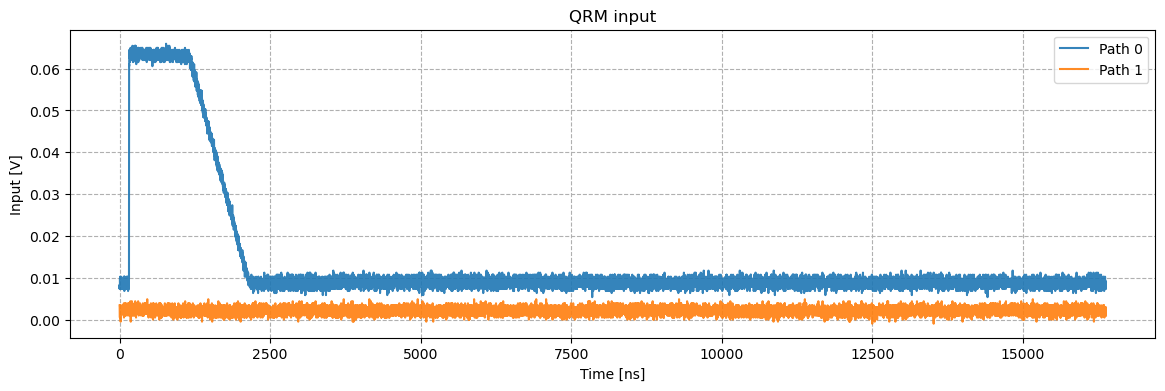

In [25]:
# Plot the results
sh.plot_input(module = qrm_module, sequencer = 1, acquisition_name = 'acq')

In [26]:
# Stop and check status
cluster.stop_sequencer()
print("QRM sequencer 0:  " + str(qrm_module.get_sequencer_status(0)))
print("QRM sequencer 1:  " + str(qrm_module.get_sequencer_status(0)))
cluster.reset()
print(cluster.get_system_status())

QRM sequencer 0:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
QRM sequencer 1:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE


Now we can try looping many times and averaging, and see the noise level decrease.

In [27]:
steps = [
	['square', 1000, 0.05],
	['ramp', 1000, 0.05, 0]
]

acquisitions = ['acq', 0, 16384]

sh.disconnect_io(qrm_module)

num_loops = 1000
# Load sequences
qrm_module.sequencer0.sequence(sh.make_output_sequence(input = steps, module = 'qrm', iterations = num_loops))
qrm_module.sequencer1.sequence(sh.make_input_sequence(input = acquisitions, iterations = num_loops))

# Connect to output and input ports
sh.connect_output(module = qrm_module, sequencer = 0, output_index = 0, path = 0)
sh.connect_input(module = qrm_module, sequencer = 1, input_index = 0, path = 0)

# Finally, arm all sequencers
qrm_module.arm_sequencer(0)
qrm_module.arm_sequencer(1)

# Start the sequence
cluster.start_sequencer()

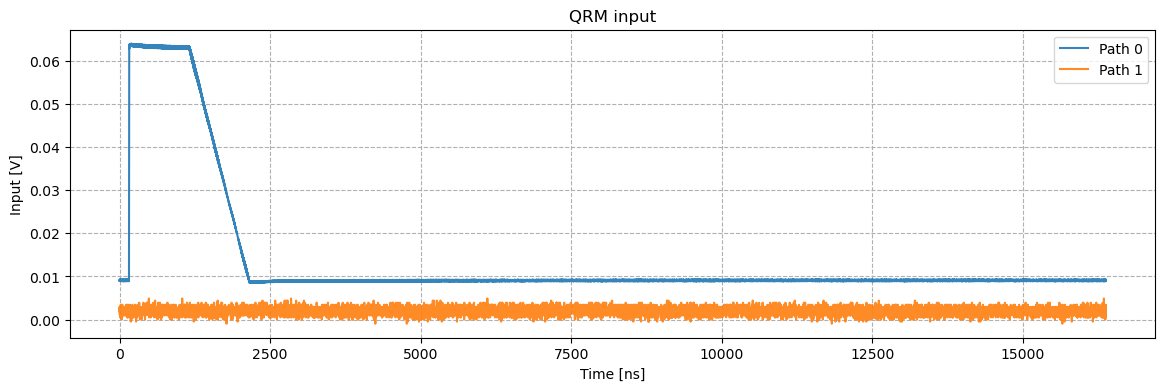

In [28]:
# Plot the results
sh.plot_input(module = qrm_module, sequencer = 1, acquisition_name = 'acq')

In [29]:
# Stop and check status
cluster.stop_sequencer()
print("QRM sequencer 0:  " + str(qrm_module.get_sequencer_status(0)))
print("QRM sequencer 1:  " + str(qrm_module.get_sequencer_status(0)))
cluster.reset()
print(cluster.get_system_status())

QRM sequencer 0:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
QRM sequencer 1:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE


Now we can also try a longer acquisition

In [30]:
steps = [
	['ramp', 0.2e6, 0, 0.2],
	['square', 0.2e6, 0.2],
	['ramp', 0.2e6, 0.2, 0]
]

acquisitions = ['acq', 0, 1e6]

sh.disconnect_io(qrm_module)

num_loops = 1
# Load sequences
qrm_module.sequencer0.sequence(sh.make_output_sequence(input = steps, module = 'qrm', iterations = num_loops))
qrm_module.sequencer1.sequence(sh.make_input_sequence(input = acquisitions, iterations = num_loops, resolution = 500))

# Connect to output and input ports
sh.connect_output(module = qrm_module, sequencer = 0, output_index = 0, path = 0)
sh.connect_input(module = qrm_module, sequencer = 1, input_index = 0, path = 0, resolution = 500)

# Finally, arm all sequencers
qrm_module.arm_sequencer(0)
qrm_module.arm_sequencer(1)

# Start the sequence
cluster.start_sequencer()

resolution for qrm output: 66


resolution in plot_input: 500


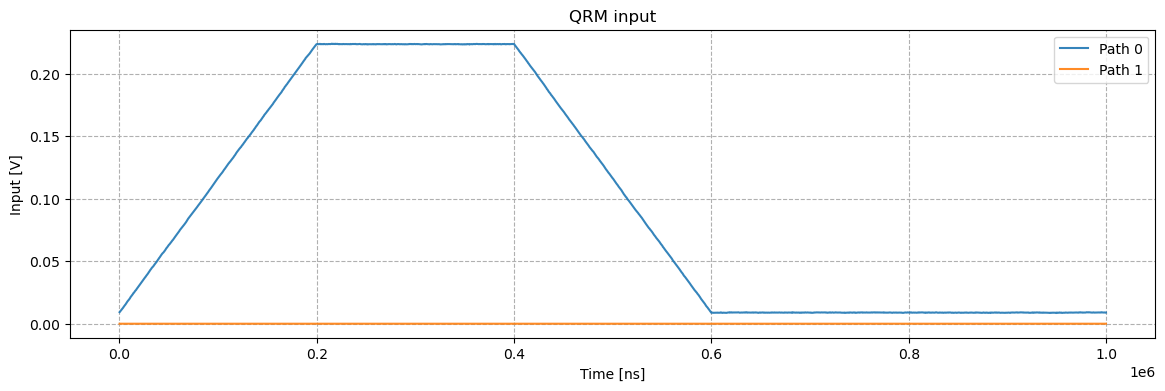

In [31]:
# Plot the results
sh.plot_input(module = qrm_module, sequencer = 1, acquisition_name = 'acq')

In [39]:
# Stop and check status
cluster.stop_sequencer()
print("QRM sequencer 0:  " + str(qrm_module.get_sequencer_status(0)))
print("QRM sequencer 1:  " + str(qrm_module.get_sequencer_status(0)))
cluster.reset()
print(cluster.get_system_status())

QRM sequencer 0:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
QRM sequencer 1:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE
